# 0. Configuración Inicial

In [1]:
#@title 0.1 Instalación
!pip install dandi
!dandi download https://gui.dandiarchive.org/#/dandiset/000128
!pip install pynwb h5py
!pip install -q wandb joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/13

In [2]:
#@title 0.2 Librerías
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score
)
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns
from IPython.display import display
import json
import joblib
import wandb


In [3]:
#@title 0.3 Paleta, estilos y paths

C = {
    'bg':     '#0d1117',
    'panel':  '#161b22',
    'border': '#30363d',
    'teal':   '#39d0c8',
    'amber':  '#f0a500',
    'red':    '#e05c5c',
    'blue':   '#58a6ff',
    'gray':   '#8b949e',
    'white':  '#e6edf3',
}

plt.rcParams.update({
    'figure.facecolor':  C['bg'],
    'axes.facecolor':    C['panel'],
    'axes.edgecolor':    C['border'],
    'axes.labelcolor':   C['white'],
    'xtick.color':       C['gray'],
    'ytick.color':       C['gray'],
    'text.color':        C['white'],
    'grid.color':        C['border'],
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

OUT = '/content/eda_outputs'
os.makedirs(OUT, exist_ok=True)

PATH_TRAIN = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'
PATH_TEST  = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb'

f_data = h5py.File(PATH_TRAIN, 'r')
print(f"Archivo de entrenamiento cargado: {PATH_TRAIN}")

# Carpetas para guardar evidencia del entrenamiento
EXP_DIR = '/content/experiment_outputs'
FIG_DIR = os.path.join(EXP_DIR, 'figures')
MODEL_DIR = os.path.join(EXP_DIR, 'models')
HF_DIR = os.path.join(EXP_DIR, 'huggingface_assets')

for d in [EXP_DIR, FIG_DIR, MODEL_DIR, HF_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Carpeta de experimento: {EXP_DIR}')


Archivo de entrenamiento cargado: /content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb
Carpeta de experimento: /content/experiment_outputs


In [4]:
#@title 0.4 Función auxiliar: tablas estilizadas

def mostrar_tabla(df, titulo):
    display(
        df.style
        .hide(axis='index')
        .set_caption(titulo)
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '18px'), ('font-weight', 'bold'),
                       ('color', '#1f4e79'), ('text-align', 'center')]},
            {'selector': 'th',
             'props': [('background-color', '#1f4e79'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center'),
                       ('border', '1px solid black')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '8px'),
                       ('border', '1px solid black')]},
            {'selector': 'table',
             'props': [('border-collapse', 'collapse'), ('margin', 'auto'),
                       ('width', '95%')]},
        ])
    )

# 1. Pre-procesamiento

In [5]:
#@title 1.1 Parámetros de extracción

# ── Ancla temporal: move_onset ─────────────────────────────────────────────
# Ventana: −200 ms antes de move_onset → +300 ms después
# Total: 500 ms → 10 bins de 50 ms cada uno
WINDOW_START_OFFSET_S = -0.20   # segundos relativo a move_onset
WINDOW_END_OFFSET_S   =  0.30   # segundos relativo a move_onset
BIN_SIZE              =  0.05   # 50 ms por bin
TIMESTEPS_INPUT       = int(round((WINDOW_END_OFFSET_S - WINDOW_START_OFFSET_S) / BIN_SIZE))  # 10
NUM_ANGULAR_CLASSES   = 8       # clases antes de filtrar

# ── Clases a excluir (bajo soporte en el dataset) ─────────────────────────
# Clase 4 (±180°) y Clase 7 (−45°) presentan soporte insuficiente.
# Esto es la causa principal de la ganancia de rendimiento en Pipeline B.
CLASSES_TO_EXCLUDE = []

print(f"Ancla temporal    : move_onset")
print(f"Ventana           : {WINDOW_START_OFFSET_S*1000:.0f} ms → +{WINDOW_END_OFFSET_S*1000:.0f} ms")
print(f"BIN_SIZE          : {BIN_SIZE*1000:.0f} ms")
print(f"TIMESTEPS_INPUT   : {TIMESTEPS_INPUT}")
print(f"Clases excluidas  : {CLASSES_TO_EXCLUDE}")

Ancla temporal    : move_onset
Ventana           : -200 ms → +300 ms
BIN_SIZE          : 50 ms
TIMESTEPS_INPUT   : 10
Clases excluidas  : []


In [6]:
#@title 1.2 Extracción de spikes por unidad

spike_times = f_data['units/spike_times'][()]
spike_idx   = f_data['units/spike_times_index'][()]
move_onset  = f_data['intervals/trials/move_onset_time'][()]

N_NEURONS = len(f_data['units/id'][()])
N_TRIALS  = len(move_onset)

# Separar spikes por neurona usando spike_times_index
# spike_idx[k] apunta al final del bloque de la neurona k
all_unit_spikes = []
prev = 0
for k in range(N_NEURONS):
    cur = spike_idx[k]
    all_unit_spikes.append(spike_times[prev:cur])
    prev = cur

print(f"Neuronas          : {N_NEURONS}")
print(f"Trials totales    : {N_TRIALS}")
print(f"Ejemplo N0 spikes : {len(all_unit_spikes[0])}")
print(f"Ejemplo N1 spikes : {len(all_unit_spikes[1])}")

Neuronas          : 182
Trials totales    : 2295
Ejemplo N0 spikes : 5811
Ejemplo N1 spikes : 6522


In [7]:
#@title 1.3 Tensor de firing rates

# Representación: spikes/s por bin (firing rate), no binario
# Shape: (N_TRIALS, TIMESTEPS_INPUT, N_NEURONS)
X_raw = np.zeros((N_TRIALS, TIMESTEPS_INPUT, N_NEURONS), dtype=np.float32)

for trial_idx in range(N_TRIALS):
    t_onset      = move_onset[trial_idx]
    t_start      = t_onset + WINDOW_START_OFFSET_S
    t_end        = t_onset + WINDOW_END_OFFSET_S

    # Bordes de bins uniformes sobre la ventana
    bins = np.linspace(t_start, t_end, TIMESTEPS_INPUT + 1)

    for unit_id in range(N_NEURONS):
        spk = all_unit_spikes[unit_id]
        spk_in = spk[(spk >= t_start) & (spk < t_end)]
        if len(spk_in) > 0:
            counts, _ = np.histogram(spk_in, bins=bins)
            X_raw[trial_idx, :, unit_id] = counts / BIN_SIZE  # firing rate en spikes/s

print(f"Shape tensor firing rates : {X_raw.shape}")
print(f"Media global (spikes/s)   : {X_raw.mean():.4f}")
print(f"Máximo global (spikes/s)  : {X_raw.max():.2f}")

Shape tensor firing rates : (2295, 10, 182)
Media global (spikes/s)   : 4.0978
Máximo global (spikes/s)  : 180.00


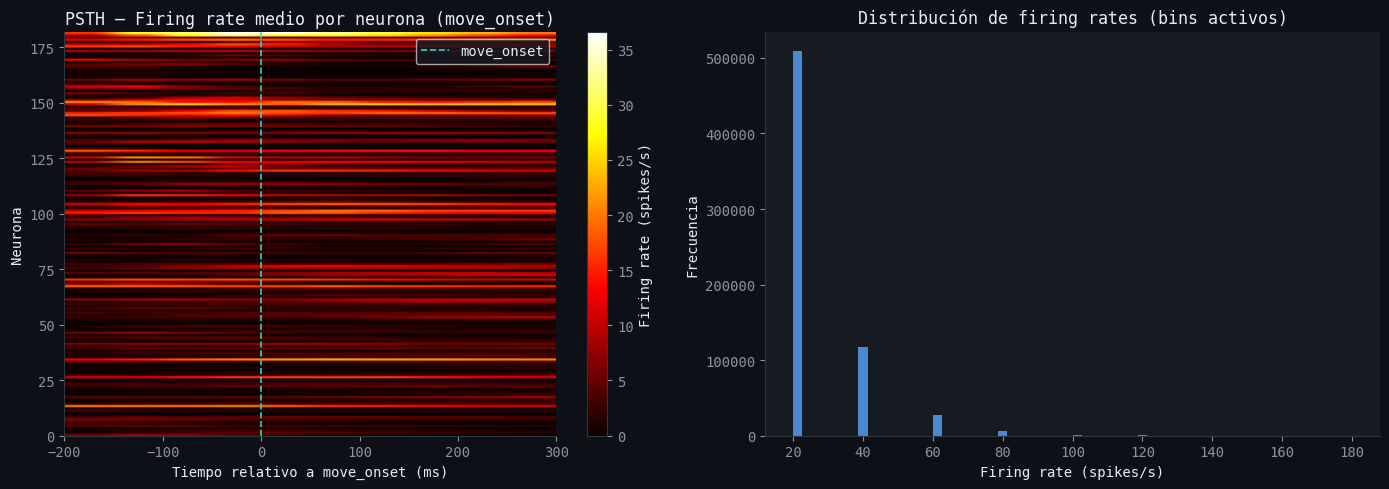

In [8]:
#@title 1.4 Representación: PSTH de firing rates

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PSTH: tasa media por neurona y bin
psth = X_raw.mean(axis=0)  # (TIMESTEPS_INPUT, N_NEURONS)
im = axes[0].imshow(psth.T, aspect='auto', origin='lower',
                    extent=[WINDOW_START_OFFSET_S*1000, WINDOW_END_OFFSET_S*1000, 0, N_NEURONS],
                    cmap='hot')
axes[0].set_xlabel("Tiempo relativo a move_onset (ms)")
axes[0].set_ylabel("Neurona")
axes[0].set_title("PSTH — Firing rate medio por neurona (move_onset)")
axes[0].axvline(0, color=C['teal'], lw=1.2, ls='--', label='move_onset')
axes[0].legend()
plt.colorbar(im, ax=axes[0], label='Firing rate (spikes/s)')

# Distribución de firing rates
axes[1].hist(X_raw[X_raw > 0].flatten(), bins=60, color=C['blue'], alpha=0.8)
axes[1].set_xlabel("Firing rate (spikes/s)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Distribución de firing rates (bins activos)")

plt.tight_layout()
plt.show()

In [9]:
#@title 1.5 Extracción de etiquetas angulares

cursor_ts  = f_data['processing/behavior/cursor_pos/timestamps'][()]
cursor_pos = f_data['processing/behavior/cursor_pos/data'][()]

# Muestreo del cursor para ventana de 500ms post-move_onset
CURSOR_FREQ = 1.0 / (cursor_ts[1] - cursor_ts[0])  # Hz
WINDOW_SAMPLES_CURSOR = int(0.5 * CURSOR_FREQ)       # 500ms

def angle_to_class(angle_deg):
    # Normalizar a [-180, 180]
    angle = ((angle_deg + 180) % 360) - 180

    borders = np.array([-157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5])
    raw_bin = np.digitize(angle, borders)

    # digitize produce:
    # 0        → angle < -157.5   → ±180°  → clase 4 (según ANGLE_NAMES original)
    # 1..7     → las 7 clases intermedias
    # 8        → angle >= 157.5   → ±180°  → clase 4 también

    mapping = {0: 4, 1: 5, 2: 6, 3: 7, 4: 0, 5: 1, 6: 2, 7: 3, 8: 4}
    return mapping[raw_bin]

ANGLE_NAMES = {
    0: '0°',     # [-22.5,   22.5)
    1: '45°',    # [ 22.5,   67.5)
    2: '90°',    # [ 67.5,  112.5)
    3: '135°',   # [112.5,  157.5)
    4: '±180°',  # [157.5,  180] ∪ [-180, -157.5)
    5: '-135°',  # [-157.5,-112.5)
    6: '-90°',   # [-112.5, -67.5)
    7: '-45°',   # [-67.5,  -22.5)
}

y_raw = np.full(N_TRIALS, -1, dtype=np.int32)

for i in range(N_TRIALS):
    idx_start = np.searchsorted(cursor_ts, move_onset[i])
    idx_end   = idx_start + WINDOW_SAMPLES_CURSOR
    if idx_end >= len(cursor_pos):
        continue
    dx = cursor_pos[idx_end][0] - cursor_pos[idx_start][0]
    dy = cursor_pos[idx_end][1] - cursor_pos[idx_start][1]
    angle_deg = np.degrees(np.arctan2(dy, dx))
    angle_clipped = np.clip(angle_deg, -179.99, 179.99)
    y_raw[i] = angle_to_class(angle_deg)

# Filtrar trials sin etiqueta válida
valid_mask = (y_raw != -1)
X_raw      = X_raw[valid_mask]
y_raw      = y_raw[valid_mask]

print(f"Trials válidos     : {len(y_raw)}")
print(f"Trials descartados : {valid_mask.shape[0] - valid_mask.sum()}")
print()

counts = Counter(y_raw)
total  = len(y_raw)
print(f"{'Clase':>6}  {'Nombre':<12}  {'N':>6}  {'%':>6}")
print("─" * 38)
for cls in range(NUM_ANGULAR_CLASSES):
    n = counts.get(cls, 0)
    print(f"{cls:>6}  {ANGLE_NAMES[cls]:<12}  {n:>6}  {n/total*100:>5.1f}%")

Trials válidos     : 2295
Trials descartados : 0

 Clase  Nombre             N       %
──────────────────────────────────────
     0  0°               269   11.7%
     1  45°              385   16.8%
     2  90°              243   10.6%
     3  135°             259   11.3%
     4  ±180°            323   14.1%
     5  -135°            341   14.9%
     6  -90°              21    0.9%
     7  -45°             454   19.8%


In [10]:
#@title 1.6. Testeo de asignación de etiquetas

def clase_esperada(angle_deg):
    borders = np.array([-157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5])
    raw_bin = np.digitize(angle_deg, borders)
    mapping = {0: 4, 1: 5, 2: 6, 3: 7, 4: 0, 5: 1, 6: 2, 7: 3, 8: 4}
    return mapping[raw_bin]

np.random.seed()
sample_idx = np.random.choice(np.where(y_raw != -1)[0], 20)

errores = 0
print(f"{'Trial':>6}  {'Ángulo (°)':>10}  {'Asignada':>9}  {'Esperada':>9}  {'Nombre':>10}  {'OK?':>5}")
print("─" * 60)
for i in sample_idx:
    idx_start = np.searchsorted(cursor_ts, move_onset[i])
    idx_end   = idx_start + WINDOW_SAMPLES_CURSOR
    dx = cursor_pos[idx_end][0] - cursor_pos[idx_start][0]
    dy = cursor_pos[idx_end][1] - cursor_pos[idx_start][1]
    angle     = np.degrees(np.arctan2(dy, dx))
    cls       = y_raw[i]
    esperada  = clase_esperada(angle)
    ok        = cls == esperada
    errores  += not ok
    flag      = '✓' if ok else f'✗ (esperada {esperada} = {ANGLE_NAMES[esperada]})'
    print(f"{i:>6}  {angle:>10.2f}  {cls:>9}  {esperada:>9}  {ANGLE_NAMES[cls]:>10}  {flag}")

print("─" * 60)
print(f"Errores detectados: {errores} / {len(sample_idx)}")
if errores == 0:
    print("Asignación correcta en todos los trials muestreados.")
else:
    print("⚠ Revisar función angle_to_class — hay inconsistencias.")

 Trial  Ángulo (°)   Asignada   Esperada      Nombre    OK?
────────────────────────────────────────────────────────────
  1480      -41.08          7          7        -45°  ✓
   613      -19.01          0          0          0°  ✓
    89       76.49          2          2         90°  ✓
  1286      -18.13          0          0          0°  ✓
  1673      165.29          4          4       ±180°  ✓
   161     -143.24          5          5       -135°  ✓
   256       31.43          1          1         45°  ✓
   801     -146.31          5          5       -135°  ✓
  1930      -24.99          7          7        -45°  ✓
   921     -145.02          5          5       -135°  ✓
   284       37.15          1          1         45°  ✓
   580     -144.97          5          5       -135°  ✓
   790     -140.94          5          5       -135°  ✓
  1242      -21.91          0          0          0°  ✓
  1297      -20.34          0          0          0°  ✓
   342      176.52          4          

In [11]:
#@title 1.7 Filtrado de clases


# Existen clases con muestras significativamente menor y degradan la clasificación
mask_classes = ~np.isin(y_raw, CLASSES_TO_EXCLUDE)
X_filtered   = X_raw[mask_classes]
y_filtered   = y_raw[mask_classes]

# Remapeo de etiquetas: Se reasignan para conservar continuidad
unique_classes = np.unique(y_filtered)          # ej: [0,1,2,3,5,6]
class_mapping  = {old: new for new, old in enumerate(unique_classes)}
y_mapped       = np.array([class_mapping[c] for c in y_filtered], dtype=np.int32)

NUM_CLASSES  = len(unique_classes)
CLASS_LABELS = [ANGLE_NAMES[c] for c in unique_classes]

print(f"Trials tras filtrado : {len(y_mapped)}")
print(f"Clases conservadas   : {unique_classes} → {CLASS_LABELS}")
print(f"NUM_CLASSES          : {NUM_CLASSES}")
print()

counts_f = Counter(y_mapped)
total_f  = len(y_mapped)
print(f"{'Clase mapeada':>14}  {'Nombre':<10}  {'N':>6}  {'%':>6}")
print("─" * 44)
for cls in range(NUM_CLASSES):
    n = counts_f.get(cls, 0)
    print(f"{cls:>14}  {CLASS_LABELS[cls]:<10}  {n:>6}  {n/total_f*100:>5.1f}%")

Trials tras filtrado : 2295
Clases conservadas   : [0 1 2 3 4 5 6 7] → ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°']
NUM_CLASSES          : 8

 Clase mapeada  Nombre           N       %
────────────────────────────────────────────
             0  0°             269   11.7%
             1  45°            385   16.8%
             2  90°            243   10.6%
             3  135°           259   11.3%
             4  ±180°          323   14.1%
             5  -135°          341   14.9%
             6  -90°            21    0.9%
             7  -45°           454   19.8%


# 2. Speración de la Data

In [12]:
#@title 2.1 Split estratificado 70/15/15

indices = np.arange(len(y_mapped))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.30, random_state=42, stratify=y_mapped)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.50, random_state=42, stratify=y_mapped[temp_idx])

# Normalización z-score: estadísticos del TRAIN ÚNICAMENTE
# Shape de X_filtered: (trials, TIMESTEPS_INPUT, N_NEURONS)
mean = X_filtered[train_idx].mean(axis=(0, 1), keepdims=True)
std  = X_filtered[train_idx].std(axis=(0, 1),  keepdims=True)

X_train = (X_filtered[train_idx] - mean) / (std + 1e-8)
X_val   = (X_filtered[val_idx]   - mean) / (std + 1e-8)
X_test  = (X_filtered[test_idx]  - mean) / (std + 1e-8)

y_train = y_mapped[train_idx]
y_val   = y_mapped[val_idx]
y_test  = y_mapped[test_idx]

# ── Verificaciones ────────────────────────────────────────────────────────
assert len(np.intersect1d(train_idx, val_idx))  == 0, 'FUGA: train ∩ val'
assert len(np.intersect1d(train_idx, test_idx)) == 0, 'FUGA: train ∩ test'
assert len(np.intersect1d(val_idx,   test_idx)) == 0, 'FUGA: val ∩ test'

print(f"Total: {len(indices)} = {len(train_idx)} train + {len(val_idx)} val + {len(test_idx)} test")
print(f"Proporciones: {len(train_idx)/len(indices):.2f} / {len(val_idx)/len(indices):.2f} / {len(test_idx)/len(indices):.2f}")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape  : {X_val.shape}")
print(f"X_test shape : {X_test.shape}")
print()
print(f"X_train media: {X_train.mean():.4f} (esperado = 0)")
print(f"X_train std  : {X_train.std():.4f}  (esperado = 1)")
print()
print(f"X_val media: {X_val.mean():.4f} (esperado ≈ 0)")
print(f"X_val std  : {X_val.std():.4f}  (esperado ≈ 1)")
print()
print(f"X_test media: {X_test.mean():.4f} (esperado ≈ 0)")
print(f"X_test std  : {X_test.std():.4f}  (esperado ≈ 1)")
print(f"Sin solapamiento entre splits: OK")
print()

print(f"{'Clase':<10} {'Total':>6} {'Train':>6} {'Val':>6} {'Test':>6}")
print("-" * 38)
for cls in range(NUM_CLASSES):
    n_t = (y_mapped == cls).sum()
    n_tr = (y_train == cls).sum()
    n_v  = (y_val   == cls).sum()
    n_te = (y_test  == cls).sum()
    print(f"{CLASS_LABELS[cls]:<10} {n_t:>6} {n_tr:>6} {n_v:>6} {n_te:>6}")

Total: 2295 = 1606 train + 344 val + 345 test
Proporciones: 0.70 / 0.15 / 0.15
X_train shape: (1606, 10, 182)
X_val shape  : (344, 10, 182)
X_test shape : (345, 10, 182)

X_train media: 0.0000 (esperado = 0)
X_train std  : 1.0000  (esperado = 1)

X_val media: -0.0059 (esperado ≈ 0)
X_val std  : 0.9876  (esperado ≈ 1)

X_test media: 0.0010 (esperado ≈ 0)
X_test std  : 1.0033  (esperado ≈ 1)
Sin solapamiento entre splits: OK

Clase       Total  Train    Val   Test
--------------------------------------
0°            269    188     40     41
45°           385    269     58     58
90°           243    170     37     36
135°          259    181     39     39
±180°         323    226     48     49
-135°         341    239     51     51
-90°           21     15      3      3
-45°          454    318     68     68


In [13]:
#@title 2.2 DataLoaders

#Pesos de clase
weights = compute_class_weight(class_weight='balanced',
                               classes=np.arange(NUM_CLASSES),
                               y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)
print(f"Class weights: {np.round(weights, 3)}")

#Tensores PyTorch
BATCH_SIZE = 64

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

#Data loader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Class weights: [ 1.068  0.746  1.181  1.109  0.888  0.84  13.383  0.631]
Train batches : 26
Val batches   : 6


# 3. Modelo LSTM

In [14]:
#@title 3.1 Hiperparámetros

LSTM1_UNITS   = 96
LSTM2_UNITS   = 64
DROPOUT1_RATE = 0.50
DROPOUT2_RATE = 0.50
L2_REG        = 0.003
LEARNING_RATE = 0.001
EPOCHS        = 200
PATIENCE_ES   = 20    # Early stopping sobre val_loss
PATIENCE_LR   = 7     # ReduceLROnPlateau

INPUT_SIZE = X_train.shape[2]  # N_NEURONS = 182

print(f"INPUT_SIZE (neuronas) : {INPUT_SIZE}")
print(f"TIMESTEPS             : {TIMESTEPS_INPUT}")
print(f"NUM_CLASSES           : {NUM_CLASSES}")
print(f"LSTM                  : {LSTM1_UNITS} → {LSTM2_UNITS} → {NUM_CLASSES}")
print(f"LEARNING_RATE         : {LEARNING_RATE}")
print(f"BATCH_SIZE            : {BATCH_SIZE}")

INPUT_SIZE (neuronas) : 182
TIMESTEPS             : 10
NUM_CLASSES           : 8
LSTM                  : 96 → 64 → 8
LEARNING_RATE         : 0.001
BATCH_SIZE            : 64


In [15]:
#@title 3.1.1 Seguimiento de experimento con W&B

# Ejecuta esta celda antes de entrenar.
# Te pedirá un API key si no has iniciado sesión en W&B.
wandb.login()

config = {
    "project": "BCI_MC_Maze_LSTM",
    "model": "LSTM",
    "input_size": int(INPUT_SIZE),
    "timesteps": int(TIMESTEPS_INPUT),
    "num_classes": int(NUM_CLASSES),
    "lstm1_units": int(LSTM1_UNITS),
    "lstm2_units": int(LSTM2_UNITS),
    "dropout1": float(DROPOUT1_RATE),
    "dropout2": float(DROPOUT2_RATE),
    "l2_reg": float(L2_REG),
    "learning_rate": float(LEARNING_RATE),
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH_SIZE),
    "early_stopping_patience": int(PATIENCE_ES),
    "lr_patience": int(PATIENCE_LR),
    "optimizer": "Adam",
    "loss": "CrossEntropyLoss",
    "split": "70/15/15 stratified",
    "normalization": "z-score fitted only on train",
    "dataset": "MC_Maze Jenkins PMd/M1",
}

run = wandb.init(
    project="BCI_MC_Maze_LSTM",
    name="LSTM_final_tensor_10x182",
    config=config
)


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: kimberly-soto (kimberly-soto-pontificia-universidad-cat-lica-del-per-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [16]:
#@title 3.2 Arquitectura

# Pooling triple (last + mean + max) :
# captura el estado final, la activación promedio y el pico máximo
# de la secuencia temporal, aumentando la riqueza de la representación.
class MotorLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(
            input_size=INPUT_SIZE,
            hidden_size=LSTM1_UNITS,
            batch_first=True
        )
        self.drop1 = nn.Dropout(DROPOUT1_RATE)
        self.lstm2 = nn.LSTM(
            input_size=LSTM1_UNITS,
            hidden_size=LSTM2_UNITS,
            batch_first=True
        )
        self.drop2 = nn.Dropout(DROPOUT2_RATE)
        # Pooling last + mean + max → 3 × LSTM2_UNITS
        self.fc = nn.Linear(LSTM2_UNITS * 3, NUM_CLASSES)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.drop1(x)
        x, _ = self.lstm2(x)
        x = self.drop2(x)
        x_last = x[:, -1, :]
        x_mean = x.mean(dim=1)
        x_max, _ = x.max(dim=1)
        x = torch.cat([x_last, x_mean, x_max], dim=1)
        return self.fc(x)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = MotorLSTM().to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights.to(device)
)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=L2_REG
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=PATIENCE_LR, factor=0.5, min_lr=1e-7
)

print(f"Dispositivo          : {device}")
print(f"Parámetros totales   : {sum(p.numel() for p in model.parameters()):,}")
print(model)

Dispositivo          : cpu
Parámetros totales   : 150,536
MotorLSTM(
  (lstm1): LSTM(182, 96, batch_first=True)
  (drop1): Dropout(p=0.5, inplace=False)
  (lstm2): LSTM(96, 64, batch_first=True)
  (drop2): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=192, out_features=8, bias=True)
)


In [17]:
#@title 3.3 Entrenamiento

best_val_loss    = float('inf')
best_state_dict  = None
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # ── Training ───────────────────────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        train_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        train_total   += len(y_batch)

    # ── Validation ─────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_loss    += loss.item() * len(y_batch)
            val_correct += (logits.argmax(dim=1) == y_batch).sum().item()
            val_total   += len(y_batch)

    t_loss = train_loss / train_total
    v_loss = val_loss   / val_total
    t_acc  = train_correct / train_total
    v_acc  = val_correct   / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    # Registrar curvas en W&B
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": t_loss,
        "val/loss": v_loss,
        "train/accuracy": t_acc,
        "val/accuracy": v_acc,
        "learning_rate": optimizer.param_groups[0]["lr"]
    })

    scheduler.step(v_loss)

    # ── Early stopping sobre val_loss con restore_best_weights ─────────────
    if v_loss < best_val_loss:
        best_val_loss   = v_loss
        best_state_dict = {k: v.clone() for k, v in model.state_dict().items()}
        torch.save(best_state_dict, os.path.join(MODEL_DIR, "best_lstm_motor.pth"))
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"train loss: {t_loss:.4f} acc: {t_acc:.3f} | "
              f"val loss: {v_loss:.4f} acc: {v_acc:.3f} | "
              f"patience: {patience_counter}/{PATIENCE_ES}")

    if patience_counter >= PATIENCE_ES:
        print(f"\nEarly stopping en época {epoch+1}")
        break

# Restaurar mejor estado (equivalente a restore_best_weights de Keras)
model.load_state_dict(best_state_dict)
print(f"\nMejor val_loss restaurado: {best_val_loss:.4f}")


Epoch  10 | train loss: 0.0916 acc: 0.983 | val loss: 0.4568 acc: 0.843 | patience: 3/20
Epoch  20 | train loss: 0.0251 acc: 0.998 | val loss: 0.5455 acc: 0.820 | patience: 13/20

Early stopping en época 27

Mejor val_loss restaurado: 0.4128


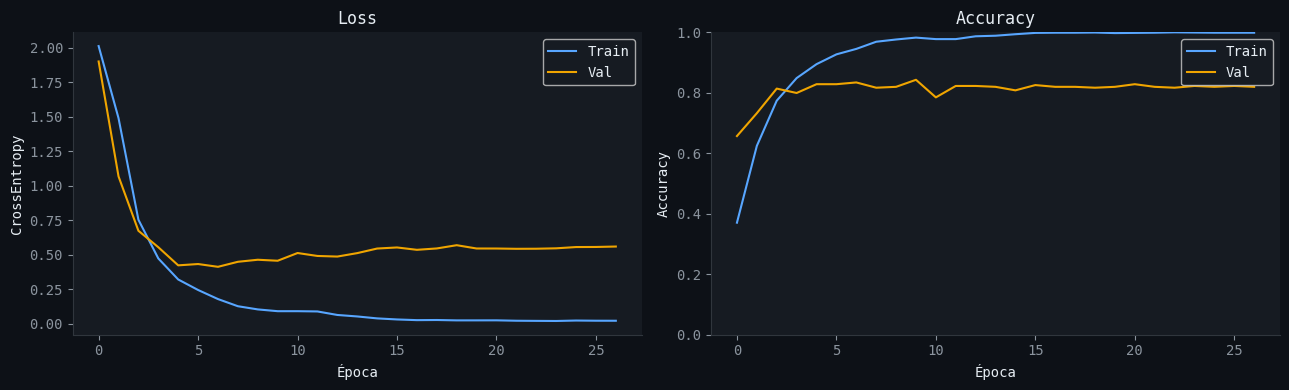

In [18]:
#@title 3.4 Curvas de entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history['train_loss'], label='Train', color=C['blue'])
ax1.plot(history['val_loss'],   label='Val',   color=C['amber'])
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('CrossEntropy')
ax1.legend()

ax2.plot(history['train_acc'], label='Train', color=C['blue'])
ax2.plot(history['val_acc'],   label='Val',   color=C['amber'])
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 1)
ax2.legend()

plt.tight_layout()
fig_path = os.path.join(FIG_DIR, 'training_curves_lstm.png')
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
wandb.log({'figures/training_curves': wandb.Image(fig_path)})
plt.show()


# 4. Evaluación Final

In [19]:
#@title 4.1 Predicciones (test)

model.eval()
all_probs, all_preds, all_labels = [], [], []

test_loader = DataLoader(TensorDataset(X_test_t, y_test_t),
                         batch_size=BATCH_SIZE, shuffle=False)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits  = model(X_batch)
        probs   = torch.softmax(logits, dim=1)
        preds   = probs.argmax(dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

y_prob = np.vstack(all_probs)
y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print(f"y_prob shape : {y_prob.shape}")
print(f"y_true shape : {y_true.shape}")
print(f"Clases únicas en test: {np.unique(y_true)}")

y_prob shape : (345, 8)
y_true shape : (345,)
Clases únicas en test: [0 1 2 3 4 5 6 7]


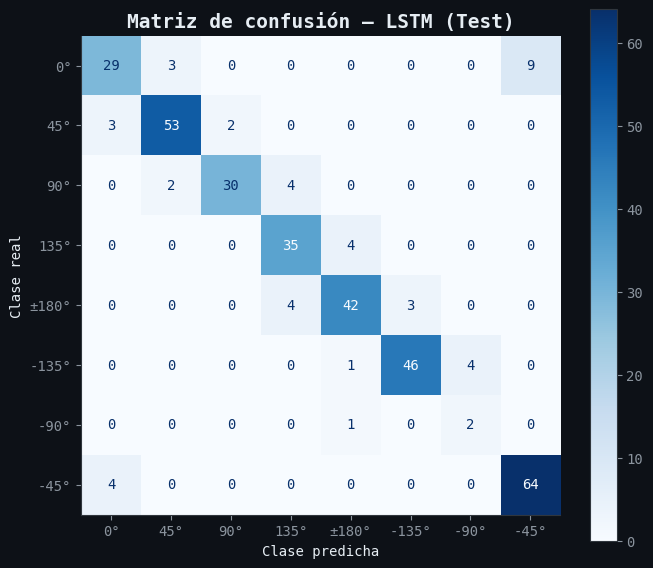

In [20]:
#@title 4.2 Matriz de confusión

n_classes    = y_prob.shape[1]
cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=True)
plt.title('Matriz de confusión — LSTM (Test)', fontsize=14, fontweight='bold')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.grid(False)
plt.tight_layout()
cm_path = os.path.join(FIG_DIR, 'confusion_matrix_lstm.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
wandb.log({'figures/confusion_matrix_lstm': wandb.Image(cm_path)})
plt.show()


In [21]:
#@title 4.3 Métricas por clase

y_true_bin   = label_binarize(y_true, classes=np.arange(n_classes))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    if len(np.unique(y_true_bin[:, i])) == 2:
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    else:
        fpr[i] = tpr[i] = None
        roc_auc[i] = np.nan

total = np.sum(cm)
metricas_clase = []
for i, label in enumerate(CLASS_LABELS):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = total - TP - FN - FP
    acc_c  = (TP + TN) / total if total > 0 else 0
    sens   = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec   = TN / (TN + FP) if (TN + FP) > 0 else 0
    prec   = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1_c   = 2*prec*sens / (prec + sens) if (prec + sens) > 0 else 0
    metricas_clase.append({
        'Clase angular': label,
        'Accuracy clase': round(acc_c, 4),
        'Sensibilidad':   round(sens, 4),
        'Especificidad':  round(spec, 4),
        'Precision':      round(prec, 4),
        'Recall':         round(sens, 4),
        'F1-score':       round(f1_c, 4),
        'AUC-ROC':        round(roc_auc[i], 4) if not np.isnan(roc_auc[i]) else 'NC',
        'Support':        int(TP + FN)
    })

tabla_clases = pd.DataFrame(metricas_clase)
mostrar_tabla(tabla_clases, 'Tabla 4. Métricas por clase del modelo LSTM')

Clase angular,Accuracy clase,Sensibilidad,Especificidad,Precision,Recall,F1-score,AUC-ROC,Support
0°,0.944900,0.707300,0.977000,0.805600,0.707300,0.753200,0.971800,41
45°,0.971000,0.913800,0.982600,0.913800,0.913800,0.913800,0.993500,58
90°,0.976800,0.833300,0.993500,0.937500,0.833300,0.882400,0.987900,36
135°,0.965200,0.897400,0.973900,0.814000,0.897400,0.853700,0.984100,39
±180°,0.962300,0.857100,0.979700,0.875000,0.857100,0.866000,0.987700,49
-135°,0.976800,0.902000,0.989800,0.938800,0.902000,0.920000,0.998100,51
-90°,0.985500,0.666700,0.988300,0.333300,0.666700,0.444400,0.989300,3
-45°,0.962300,0.941200,0.967500,0.876700,0.941200,0.907800,0.990000,68


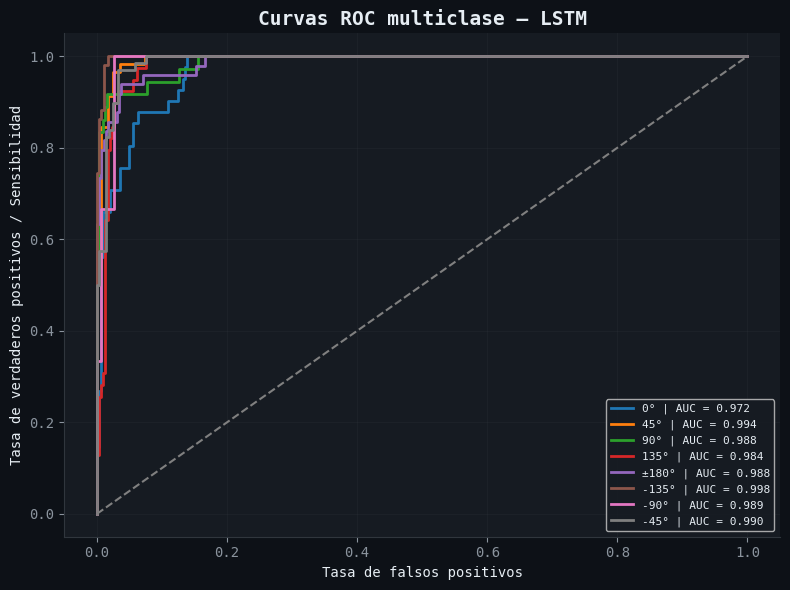

In [22]:
#@title 4.4 Curvas ROC multiclase

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    if fpr[i] is not None:
        plt.plot(fpr[i], tpr[i], linewidth=2,
                 label=f'{CLASS_LABELS[i]} | AUC = {roc_auc[i]:.3f}')

plt.plot([0, 1], [0, 1], ls='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos / Sensibilidad')
plt.title('Curvas ROC multiclase — LSTM', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
roc_path = os.path.join(FIG_DIR, 'roc_lstm.png')
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
wandb.log({'figures/roc_lstm': wandb.Image(roc_path)})
plt.show()


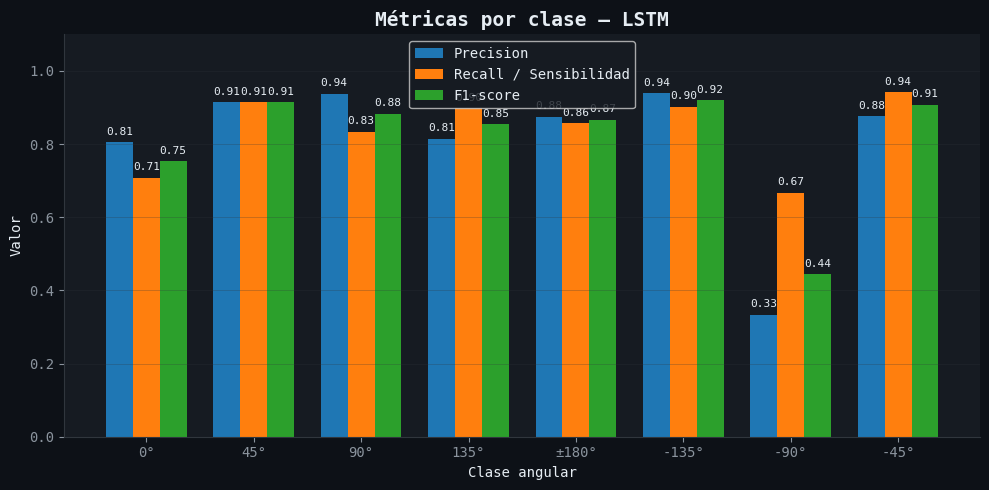

In [23]:
#@title 4.5 Gráfico de métricas por clase

prec_vals  = tabla_clases['Precision'].astype(float).values
recall_vals = tabla_clases['Recall'].astype(float).values
f1_vals     = tabla_clases['F1-score'].astype(float).values

x     = np.arange(len(CLASS_LABELS))
width = 0.25

plt.figure(figsize=(10, 5))
b1 = plt.bar(x - width, prec_vals,   width, label='Precision')
b2 = plt.bar(x,         recall_vals, width, label='Recall / Sensibilidad')
b3 = plt.bar(x + width, f1_vals,     width, label='F1-score')

plt.xticks(x, CLASS_LABELS)
plt.ylim(0, 1.1)
plt.xlabel('Clase angular')
plt.ylabel('Valor')
plt.title('Métricas por clase — LSTM', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.015,
                 f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
#@title 4.6 Métricas globales

accuracy       = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
recall_macro    = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1_macro        = f1_score(y_true, y_pred, average='macro', zero_division=0)

try:
    auc_macro = roc_auc_score(y_true_bin, y_prob, average='macro',  multi_class='ovr')
    auc_micro = roc_auc_score(y_true_bin, y_prob, average='micro',  multi_class='ovr')
except Exception as e:
    print(f'AUC-ROC no calculable: {e}')
    auc_macro = auc_micro = np.nan

tabla_globales = pd.DataFrame({
    'Métrica': ['Accuracy', 'Sensibilidad / Recall Macro',
                'Precision Macro', 'F1-score Macro',
                'AUC-ROC Macro', 'AUC-ROC Micro'],
    'Valor': [
        round(accuracy, 4), round(recall_macro, 4),
        round(precision_macro, 4), round(f1_macro, 4),
        round(auc_macro, 4) if not np.isnan(auc_macro) else 'No calculable',
        round(auc_micro, 4) if not np.isnan(auc_micro) else 'No calculable',
    ]
})

mostrar_tabla(tabla_globales, 'Tabla 1. Métricas globales del modelo LSTM — Test')

# Guardar métricas globales en archivos y en W&B
metrics_lstm = {
    "test/accuracy": float(accuracy),
    "test/precision_macro": float(precision_macro),
    "test/recall_macro": float(recall_macro),
    "test/f1_macro": float(f1_macro),
    "test/auc_macro": float(auc_macro) if not np.isnan(auc_macro) else None,
    "test/auc_micro": float(auc_micro) if not np.isnan(auc_micro) else None,
}

pd.DataFrame([metrics_lstm]).to_csv(os.path.join(EXP_DIR, "metrics_lstm_global.csv"), index=False)

with open(os.path.join(EXP_DIR, "metrics_lstm_global.json"), "w") as f:
    json.dump(metrics_lstm, f, indent=4)

wandb.log(metrics_lstm)


Métrica,Valor
Accuracy,0.872500
Sensibilidad / Recall Macro,0.839900
Precision Macro,0.811800
F1-score Macro,0.817700
AUC-ROC Macro,0.987800
AUC-ROC Micro,0.990200


#5. Modelo SVM

In [25]:
#@title 5.1 Entrenamiento y Test

# ── Reshape: (trials, timesteps, neuronas) → (trials, timesteps × neuronas) ──
X_train_svm = X_train.reshape(len(X_train), -1)
X_val_svm   = X_val.reshape(len(X_val),   -1)
X_test_svm  = X_test.reshape(len(X_test),  -1)

# ── Entrenamiento ─────────────────────────────────────────────────────────
svm = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_svm, y_train)

# ── Predicciones ──────────────────────────────────────────────────────────
y_pred_svm      = svm.predict(X_test_svm)
y_prob_svm      = svm.predict_proba(X_test_svm)

# ── Métricas ──────────────────────────────────────────────────────────────
acc_svm = accuracy_score(y_true, y_pred_svm)
f1_svm  = f1_score(y_true, y_pred_svm, average='macro', zero_division=0)

print(f"SVM — Accuracy : {acc_svm:.4f}")
print(f"SVM — F1 macro : {f1_svm:.4f}")

SVM — Accuracy : 0.8464
SVM — F1 macro : 0.7381


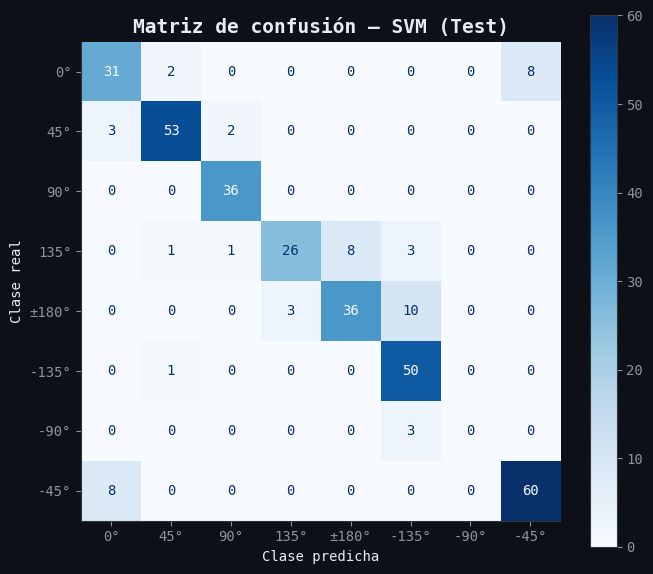

In [26]:
#@title 5.2. Matriz de confusión

cm_svm = confusion_matrix(y_true, y_pred_svm, labels=np.arange(NUM_CLASSES))

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CLASS_LABELS)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=True)
plt.title('Matriz de confusión — SVM (Test)', fontsize=14, fontweight='bold')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.grid(False)
plt.tight_layout()
plt.show()

In [27]:
#@title 5.3 Métricas por clase

y_true_bin_svm = label_binarize(y_true, classes=np.arange(NUM_CLASSES))

fpr_svm, tpr_svm, roc_auc_svm = {}, {}, {}
for i in range(NUM_CLASSES):
    if len(np.unique(y_true_bin_svm[:, i])) == 2:
        fpr_svm[i], tpr_svm[i], _ = roc_curve(y_true_bin_svm[:, i], y_prob_svm[:, i])
        roc_auc_svm[i] = auc(fpr_svm[i], tpr_svm[i])
    else:
        fpr_svm[i] = tpr_svm[i] = None
        roc_auc_svm[i] = np.nan

total_svm = np.sum(cm_svm)
metricas_svm = []
for i, label in enumerate(CLASS_LABELS):
    TP = cm_svm[i, i]
    FN = cm_svm[i, :].sum() - TP
    FP = cm_svm[:, i].sum() - TP
    TN = total_svm - TP - FN - FP
    acc_c  = (TP + TN) / total_svm if total_svm > 0 else 0
    sens   = TP / (TP + FN) if (TP + FN) > 0 else 0
    spec   = TN / (TN + FP) if (TN + FP) > 0 else 0
    prec   = TP / (TP + FP) if (TP + FP) > 0 else 0
    f1_c   = 2*prec*sens / (prec + sens) if (prec + sens) > 0 else 0
    metricas_svm.append({
        'Clase angular':  label,
        'Accuracy clase': round(acc_c, 4),
        'Sensibilidad':   round(sens,  4),
        'Especificidad':  round(spec,  4),
        'Precision':      round(prec,  4),
        'Recall':         round(sens,  4),
        'F1-score':       round(f1_c,  4),
        'AUC-ROC':        round(roc_auc_svm[i], 4) if not np.isnan(roc_auc_svm[i]) else 'NC',
        'Support':        int(TP + FN)
    })

tabla_svm = pd.DataFrame(metricas_svm)
mostrar_tabla(tabla_svm, 'Tabla X. Métricas por clase — SVM (Test)')

Clase angular,Accuracy clase,Sensibilidad,Especificidad,Precision,Recall,F1-score,AUC-ROC,Support
0°,0.939100,0.756100,0.963800,0.738100,0.756100,0.747000,0.972000,41
45°,0.973900,0.913800,0.986100,0.929800,0.913800,0.921700,0.987400,58
90°,0.991300,1.000000,0.990300,0.923100,1.000000,0.960000,0.997400,36
135°,0.953600,0.666700,0.990200,0.896600,0.666700,0.764700,0.990400,39
±180°,0.939100,0.734700,0.973000,0.818200,0.734700,0.774200,0.978100,49
-135°,0.950700,0.980400,0.945600,0.757600,0.980400,0.854700,0.994300,51
-90°,0.991300,0.000000,1.000000,0.000000,0.000000,0.000000,0.999000,3
-45°,0.953600,0.882400,0.971100,0.882400,0.882400,0.882400,0.992400,68


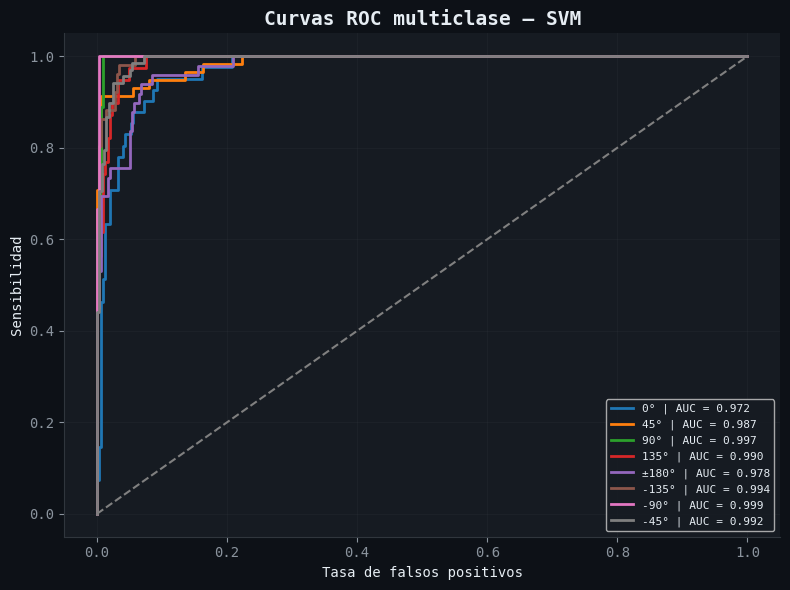

In [28]:
#@title 5.4 Curvas AUC-ROC

plt.figure(figsize=(8, 6))
for i in range(NUM_CLASSES):
    if fpr_svm[i] is not None:
        plt.plot(fpr_svm[i], tpr_svm[i], linewidth=2,
                 label=f'{CLASS_LABELS[i]} | AUC = {roc_auc_svm[i]:.3f}')
plt.plot([0, 1], [0, 1], ls='--', color='gray')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Sensibilidad')
plt.title('Curvas ROC multiclase — SVM', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Métrica,LSTM,SVM
Accuracy,0.872500,0.846400
Precision macro,0.811800,0.743200
Recall macro,0.839900,0.741700
F1 macro,0.817700,0.738100
AUC-ROC macro,0.987800,0.988900


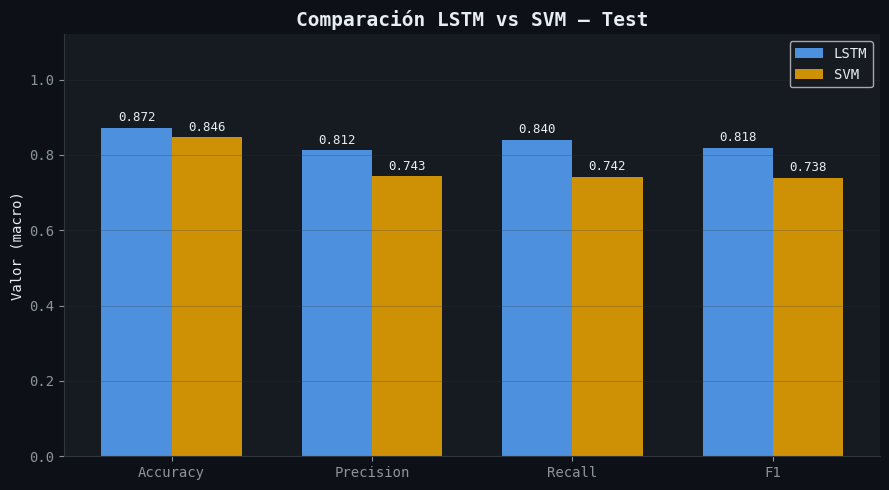

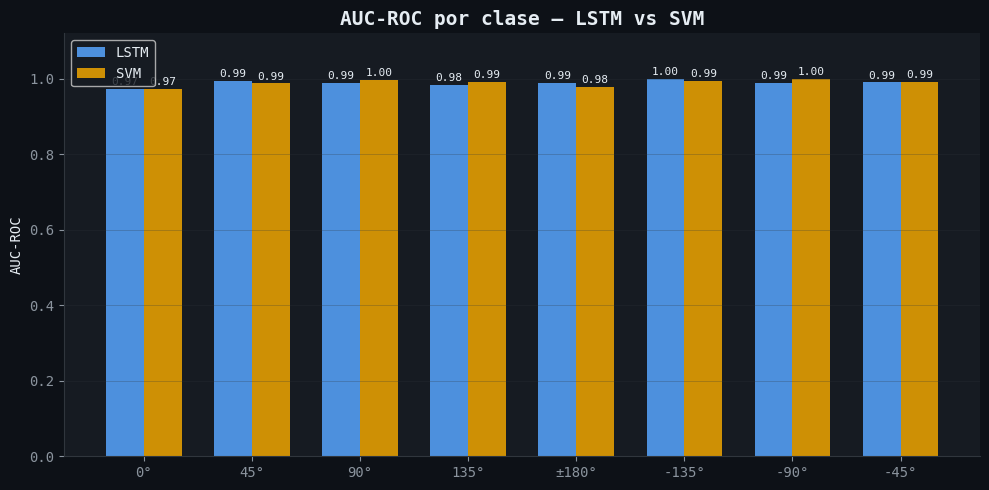

In [29]:
#@title 5.5 Comparación LSTM vs SVM

# ── Métricas globales ─────────────────────────────────────────────────────
try:
    auc_macro_lstm = roc_auc_score(y_true_bin,     y_prob,     average='macro', multi_class='ovr')
    auc_macro_svm  = roc_auc_score(y_true_bin_svm, y_prob_svm, average='macro', multi_class='ovr')
except:
    auc_macro_lstm = auc_macro_svm = np.nan

tabla_comp = pd.DataFrame({
    'Métrica':   ['Accuracy', 'Precision macro', 'Recall macro', 'F1 macro', 'AUC-ROC macro'],
    'LSTM':  [
        round(accuracy_score(y_true, y_pred),                                        4),
        round(precision_score(y_true, y_pred, average='macro', zero_division=0),     4),
        round(recall_score(y_true, y_pred,    average='macro', zero_division=0),     4),
        round(f1_score(y_true, y_pred,        average='macro', zero_division=0),     4),
        round(auc_macro_lstm, 4) if not np.isnan(auc_macro_lstm) else 'NC',
    ],
    'SVM': [
        round(accuracy_score(y_true, y_pred_svm),                                        4),
        round(precision_score(y_true, y_pred_svm, average='macro', zero_division=0),     4),
        round(recall_score(y_true, y_pred_svm,    average='macro', zero_division=0),     4),
        round(f1_score(y_true, y_pred_svm,        average='macro', zero_division=0),     4),
        round(auc_macro_svm, 4) if not np.isnan(auc_macro_svm) else 'NC',
    ],
})

mostrar_tabla(tabla_comp, 'Tabla X. Comparación global LSTM vs SVM — Test')

# ── Gráfico de barras comparativo ─────────────────────────────────────────
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1']
vals_lstm = [
    accuracy_score(y_true, y_pred),
    precision_score(y_true, y_pred, average='macro', zero_division=0),
    recall_score(y_true, y_pred,    average='macro', zero_division=0),
    f1_score(y_true, y_pred,        average='macro', zero_division=0),
]
vals_svm = [
    accuracy_score(y_true, y_pred_svm),
    precision_score(y_true, y_pred_svm, average='macro', zero_division=0),
    recall_score(y_true, y_pred_svm,    average='macro', zero_division=0),
    f1_score(y_true, y_pred_svm,        average='macro', zero_division=0),
]

x     = np.arange(len(metricas_nombres))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, vals_lstm, width, label='LSTM', color=C['blue'],  alpha=0.85)
b2 = ax.bar(x + width/2, vals_svm,  width, label='SVM',  color=C['amber'], alpha=0.85)

for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Valor (macro)')
ax.set_title('Comparación LSTM vs SVM — Test', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# ── Comparación AUC-ROC por clase ─────────────────────────────────────────
auc_lstm_clase = [round(roc_auc[i],     4) if not np.isnan(roc_auc[i])     else 0 for i in range(NUM_CLASSES)]
auc_svm_clase  = [round(roc_auc_svm[i], 4) if not np.isnan(roc_auc_svm[i]) else 0 for i in range(NUM_CLASSES)]

x2 = np.arange(NUM_CLASSES)
fig, ax = plt.subplots(figsize=(10, 5))
b3 = ax.bar(x2 - width/2, auc_lstm_clase, width, label='LSTM', color=C['blue'],  alpha=0.85)
b4 = ax.bar(x2 + width/2, auc_svm_clase,  width, label='SVM',  color=C['amber'], alpha=0.85)

for bars in [b3, b4]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x2)
ax.set_xticklabels(CLASS_LABELS)
ax.set_ylim(0, 1.12)
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC por clase — LSTM vs SVM', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Guardar comparación LSTM vs SVM
tabla_comp.to_csv(os.path.join(EXP_DIR, "comparison_lstm_vs_svm.csv"), index=False)
wandb.log({"tables/comparison_lstm_vs_svm": wandb.Table(dataframe=tabla_comp)})


In [30]:
#@title 5.6 Guardar pesos y archivos para Hugging Face

# Normalización usada en el entrenamiento
np.save(os.path.join(HF_DIR, 'norm_mean.npy'), mean)
np.save(os.path.join(HF_DIR, 'norm_std.npy'),  std)

# Modelo LSTM entrenado
torch.save(model.state_dict(), os.path.join(HF_DIR, 'lstm_motor.pth'))

# Modelo SVM baseline
joblib.dump(svm, os.path.join(MODEL_DIR, 'svm_motor.joblib'))

# Etiquetas y configuración mínima para demo
labels_dict = {int(i): str(CLASS_LABELS[i]) for i in range(NUM_CLASSES)}
with open(os.path.join(HF_DIR, 'labels.json'), 'w') as f:
    json.dump(labels_dict, f, indent=4)

config_hf = {
    "input_size": int(INPUT_SIZE),
    "timesteps": int(TIMESTEPS_INPUT),
    "num_classes": int(NUM_CLASSES),
    "lstm1_units": int(LSTM1_UNITS),
    "lstm2_units": int(LSTM2_UNITS),
    "dropout1": float(DROPOUT1_RATE),
    "dropout2": float(DROPOUT2_RATE),
    "class_labels": [str(x) for x in CLASS_LABELS],
    "expected_input_shape": [int(TIMESTEPS_INPUT), int(INPUT_SIZE)]
}
with open(os.path.join(HF_DIR, 'config.json'), 'w') as f:
    json.dump(config_hf, f, indent=4)

# Guardar algunas muestras reales de test para probar el demo
np.save(os.path.join(HF_DIR, 'sample_test_signal.npy'), X_test[0])
np.save(os.path.join(HF_DIR, 'sample_test_label.npy'), np.array(y_test[0]))

# Registrar archivos en W&B como artefacto
artifact = wandb.Artifact(
    name="lstm_motor_huggingface_assets",
    type="model",
    description="Modelo LSTM, normalización y configuración para demo en Hugging Face"
)
for filename in os.listdir(HF_DIR):
    artifact.add_file(os.path.join(HF_DIR, filename))
wandb.log_artifact(artifact)

wandb.finish()

print("Archivos guardados en:", HF_DIR)
print("Archivos generados:")
for filename in os.listdir(HF_DIR):
    print(" -", filename)


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
learning_rate,███████████████▃▃▃▃▃▃▃▃▁▁▁▁
test/accuracy,▁
test/auc_macro,▁
test/auc_micro,▁
test/f1_macro,▁
test/precision_macro,▁
test/recall_macro,▁
train/accuracy,▁▄▅▆▇▇▇████████████████████
train/loss,█▆▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+2,...


Archivos guardados en: /content/experiment_outputs/huggingface_assets
Archivos generados:
 - config.json
 - norm_std.npy
 - norm_mean.npy
 - sample_test_label.npy
 - sample_test_signal.npy
 - labels.json
 - lstm_motor.pth


#6. Caso de Uso Concreto

Etapa,Descripción
Muestra evaluada,Trial aleatorio del conjunto de test — índice interno 252
Entrada,Ventana de actividad neuronal del conjunto no visto
Preprocesamiento aplicado,Firing rates + z-score | move_onset −200ms/+300ms
Representación,Tensor temporal (10 bins × 182 neuronas)
Modelo,"LSTM(96)→LSTM(64), pooling L+M+Max"
Etiqueta real,-135°
Predicción,-135°
Probabilidad asociada,0.891600
Resultado interpretable,Clasificación correcta: dirección motora predicha -135°


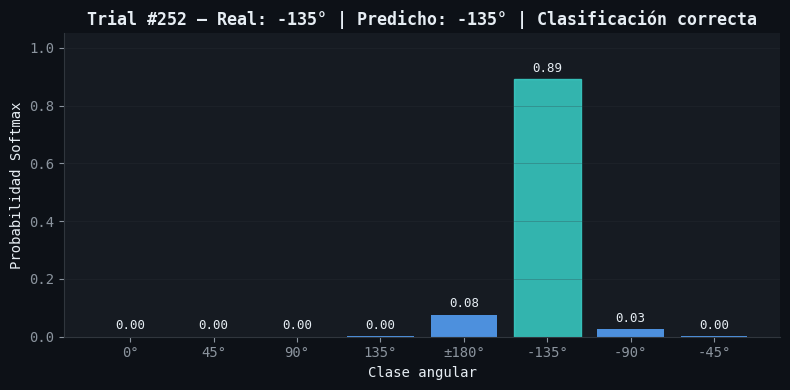

In [31]:
#@title 6.2 Caso Aleatorio

# Selección aleatoria de un trial del conjunto de test
np.random.seed()
idx_case = np.random.randint(0, len(y_true))

# Recuperar etiqueta real, predicción y probabilidad asociada a la clase predicha
real_label = CLASS_LABELS[int(y_true[idx_case])]
pred_label = CLASS_LABELS[int(y_pred[idx_case])]
prob_pred  = float(y_prob[idx_case, int(y_pred[idx_case])])
resultado  = 'Clasificación correcta' if y_true[idx_case] == y_pred[idx_case] else 'Clasificación incorrecta'

# Tabla narrativa: recorrido completo del trial a través del pipeline
tabla_caso = pd.DataFrame({
    'Etapa': [
        'Muestra evaluada', 'Entrada', 'Preprocesamiento aplicado',
        'Representación', 'Modelo', 'Etiqueta real',
        'Predicción', 'Probabilidad asociada', 'Resultado interpretable'
    ],
    'Descripción': [
        f'Trial aleatorio del conjunto de test — índice interno {idx_case}',
        'Ventana de actividad neuronal del conjunto no visto',
        f'Firing rates + z-score | move_onset −200ms/+300ms',
        f'Tensor temporal ({TIMESTEPS_INPUT} bins × {N_NEURONS} neuronas)',
        f'LSTM({LSTM1_UNITS})→LSTM({LSTM2_UNITS}), pooling L+M+Max',
        real_label,
        pred_label,
        round(prob_pred, 4),
        f'{resultado}: dirección motora predicha {pred_label}'
    ]
})
mostrar_tabla(tabla_caso, f'Tabla 5. Caso de uso — Trial aleatorio #{idx_case}')

# Gráfico de probabilidades softmax sobre todas las clases
# La barra más alta es la clase predicha
# Si varias barras son similares → el modelo está indeciso entre direcciones
plt.figure(figsize=(8, 4))
bars  = plt.bar(CLASS_LABELS, y_prob[idx_case], color=C['blue'], alpha=0.85)
color_override = C['teal'] if y_true[idx_case] == y_pred[idx_case] else C['red']
bars[int(y_pred[idx_case])].set_color(color_override)

plt.ylim(0, 1.05)
plt.xlabel('Clase angular')
plt.ylabel('Probabilidad Softmax')
plt.title(f'Trial #{idx_case} — Real: {real_label} | Predicho: {pred_label} | {resultado}',
          fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.015,
             f'{h:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# 7. Representación del Pipeline

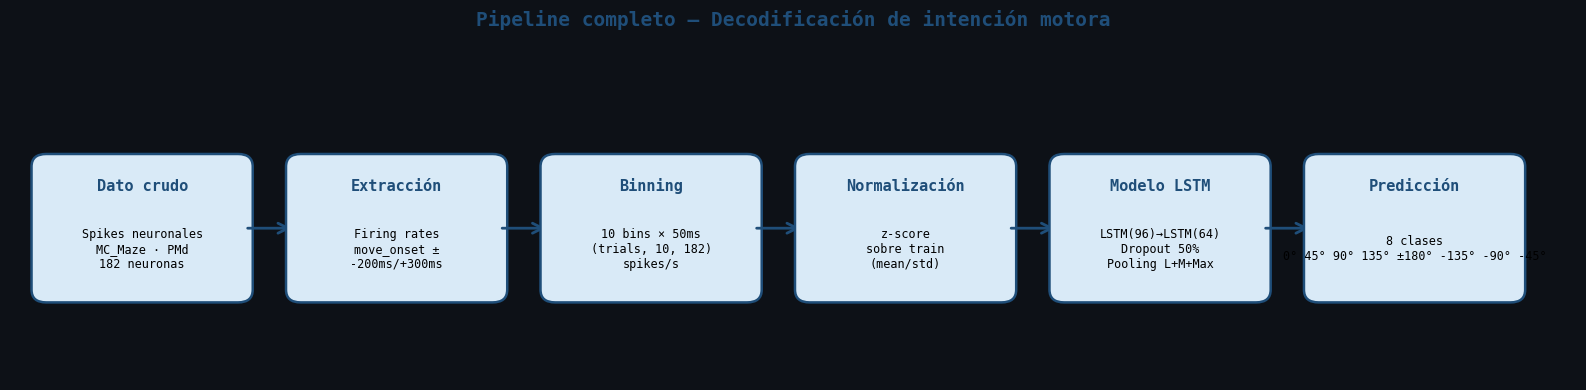

In [32]:
#@title 7.1 Diagrama de flujo

fig, ax = plt.subplots(figsize=(16, 4))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4)
ax.axis('off')

steps = [
    ('Dato crudo',      'Spikes neuronales\nMC_Maze · PMd\n182 neuronas'),
    ('Extracción',      'Firing rates\nmove_onset ±\n-200ms/+300ms'),
    ('Binning',         '10 bins × 50ms\n(trials, 10, 182)\nspikes/s'),
    ('Normalización',   'z-score\nsobre train\n(mean/std)'),
    ('Modelo LSTM',     'LSTM(96)→LSTM(64)\nDropout 50%\nPooling L+M+Max'),
    ('Predicción',      f'{NUM_CLASSES} clases\n' + ' '.join(CLASS_LABELS)),
]

x_positions = [0.3 + i * 2.6 for i in range(len(steps))]
box_w, box_h, y_box = 2.1, 1.6, 1.0

for i, (title, desc) in enumerate(steps):
    x_pos = x_positions[i]
    box = FancyBboxPatch((x_pos, y_box), box_w, box_h,
                          boxstyle='round,pad=0.08,rounding_size=0.15',
                          linewidth=1.8, edgecolor='#1f4e79', facecolor='#d9eaf7')
    ax.add_patch(box)
    ax.text(x_pos + box_w/2, y_box + box_h - 0.3, title,
            ha='center', va='center', fontsize=11, fontweight='bold', color='#1f4e79')
    ax.text(x_pos + box_w/2, y_box + 0.55, desc,
            ha='center', va='center', fontsize=8.5, color='black')
    if i < len(steps) - 1:
        arr = FancyArrowPatch((x_pos + box_w, y_box + box_h/2),
                               (x_positions[i+1], y_box + box_h/2),
                               arrowstyle='->', mutation_scale=18,
                               linewidth=2, color='#1f4e79')
        ax.add_patch(arr)

plt.title('Pipeline completo — Decodificación de intención motora',
          fontsize=14, fontweight='bold', color='#1f4e79', pad=12)
plt.tight_layout()
plt.show()

In [33]:
#@title 7.2 Tabla del pipeline

tabla_pipeline = pd.DataFrame({
    'Etapa': [
        'Dato crudo', 'Extracción', 'Representación',
        'Normalización', 'Modelo', 'Predicción', 'Resultado'
    ],
    'Descripción': [
        'Trenes de spikes (spike_times) por trial en MC_Maze',
        'Firing rates (spikes/s) en ventana ±200/+300ms respecto a move_onset',
        f'Tensor (trials × {TIMESTEPS_INPUT} bins × {N_NEURONS} neuronas)',
        'z-score sobre train; aplicado a val/test sin reajuste',
        f'LSTM({LSTM1_UNITS})→LSTM({LSTM2_UNITS}), Dropout {DROPOUT1_RATE}, pooling L+M+Max, Softmax',
        f'{NUM_CLASSES} clases angulares: ' + ', '.join(CLASS_LABELS),
        'Dirección motora estimada en tiempo real'
    ]
})

mostrar_tabla(tabla_pipeline, 'Tabla 1. Pipeline completo de extremo a extremo')

Etapa,Descripción
Dato crudo,Trenes de spikes (spike_times) por trial en MC_Maze
Extracción,Firing rates (spikes/s) en ventana ±200/+300ms respecto a move_onset
Representación,Tensor (trials × 10 bins × 182 neuronas)
Normalización,z-score sobre train; aplicado a val/test sin reajuste
Modelo,"LSTM(96)→LSTM(64), Dropout 0.5, pooling L+M+Max, Softmax"
Predicción,"8 clases angulares: 0°, 45°, 90°, 135°, ±180°, -135°, -90°, -45°"
Resultado,Dirección motora estimada en tiempo real


In [34]:
#@title 7.3 Tabla del sistema final

tabla_sistema = pd.DataFrame({
    'Elemento': [
        'Entrada del sistema', 'Tipo de señal', 'Ancla temporal',
        'Ventana analizada', 'Resolución temporal', 'Número de canales',
        'Modelo final', 'Salida del sistema',
        'Clases conservadas', 'Clases excluidas'
    ],
    'Descripción': [
        'Ventana de actividad neuronal por trial',
        'Firing rates (spikes/s) por bin de 50 ms',
        'move_onset (inicio de ejecución motora)',
        f'{WINDOW_START_OFFSET_S*1000:.0f} ms → +{WINDOW_END_OFFSET_S*1000:.0f} ms',
        f'{TIMESTEPS_INPUT} bins × {BIN_SIZE*1000:.0f} ms',
        f'{N_NEURONS} canales neuronales (PMd)',
        f'LSTM({LSTM1_UNITS})→LSTM({LSTM2_UNITS}), pooling L+M+Max',
        'Clase angular predicha (softmax)',
        ', '.join(CLASS_LABELS),
        ', '.join([ANGLE_NAMES[c] for c in CLASSES_TO_EXCLUDE]) + ' (bajo soporte)'
    ]
})

mostrar_tabla(tabla_sistema, 'Tabla 2. Descripción del sistema final')

Elemento,Descripción
Entrada del sistema,Ventana de actividad neuronal por trial
Tipo de señal,Firing rates (spikes/s) por bin de 50 ms
Ancla temporal,move_onset (inicio de ejecución motora)
Ventana analizada,-200 ms → +300 ms
Resolución temporal,10 bins × 50 ms
Número de canales,182 canales neuronales (PMd)
Modelo final,"LSTM(96)→LSTM(64), pooling L+M+Max"
Salida del sistema,Clase angular predicha (softmax)
Clases conservadas,"0°, 45°, 90°, 135°, ±180°, -135°, -90°, -45°"
Clases excluidas,(bajo soporte)
